**Gerekli Kütüphanelerin Kurulması**

In [1]:
!pip install optuna shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 6.6 MB/s eta 0:00:00


Öncelikle optuna ve shap kütüphanleri yüklenildi. Google Colab da çalışıldı. Optuna, makine öğrenimi modellerinde optimum hiperparametre değerlerinin aranmasını otomatikleştiren bir hiperparametre optimizasyon çerçevesidir. SHAP ise, makine öğrenimi modellerinin çıktısını açıklamaya yardımcı olur ve her bir özelliğin bir tahmine nasıl katkıda bulunduğunu göstererek daha yorumlanabilir hale getirir. Optuna ve SHAP yüklendikten sonra veri analizi için ilgili Pyhthon kütüphanleri içe aktarıldı.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)

import optuna
import shap
import warnings

warnings.filterwarnings("ignore")

# For consistent plots
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


**1. Veri Setinin Yüklenmesi**

**1.1 scikit-learn’den Veri Seti Yükleme ve 1.2 Veri Çerçevesi Oluşturma**

In [3]:
# Load Dataset from scikit-learn (Breast Cancer Wisconsin)

data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

# Create DataFrame
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
df.head()


Shape of X: (569, 30)
Shape of y: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
print("Dataset shape:", df.shape)


Dataset shape: (569, 31)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

**2. Veri Seti Kalite Kontrolleri**

**2.1 Eksik Değer Analizi**

In [6]:
# Missing Value Analysis

missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)




Missing values per column:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


**2.2 Aykırı Değer Analizi**

Number of outliers (|z|>5) per feature:


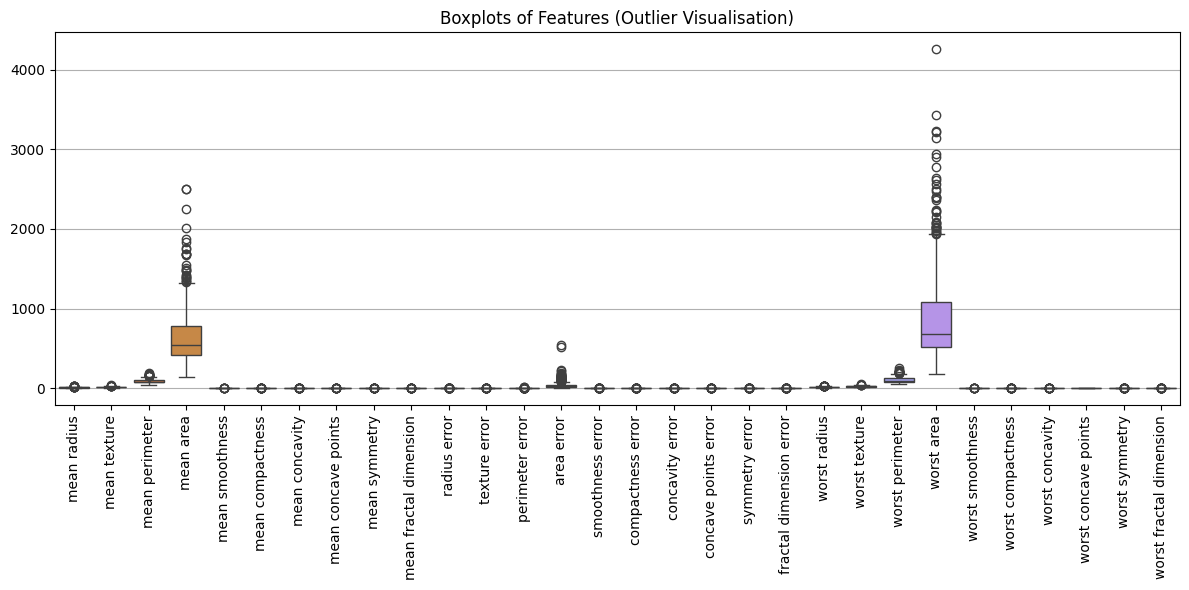

In [7]:
from scipy import stats

# Outlier Analysis using Z-score for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove("target")  # only features

z_scores = np.abs(stats.zscore(df[numeric_cols]))
outlier_mask = (z_scores > 5)
outlier_counts = outlier_mask.sum(axis=0)

print("Number of outliers (|z|>5) per feature:")
outlier_counts

# Optional: Visual inspection with boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=90)
plt.title("Boxplots of Features (Outlier Visualisation)")
plt.tight_layout()
plt.show()


**2.3 Veri Tipi ve Dağılım İncelemesi**

In [8]:
# Data Type and Distribution Review

print("Data types:")
print(df.dtypes)

num_vars = df.select_dtypes(include=[np.number]).shape[1]
cat_vars = df.select_dtypes(exclude=[np.number]).shape[1]

print(f"\nNumber of numeric variables: {num_vars}")
print(f"Number of categorical variables: {cat_vars}")

df.describe().T.head()


Data types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst sy

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634


**3.Keşifsel Veri Analizi EDA**

**3.1 İstatiksel Özellikler**

In [9]:
# Statistical Properties for each feature

stats_df = df[numeric_cols + ["target"]].describe(percentiles=[0.25, 0.5, 0.75]).T
stats_df.rename(columns={"25%": "Q1", "50%": "Median", "75%": "Q3"}, inplace=True)
stats_df[["mean", "Median", "min", "max", "std", "Q1", "Q3"]]  # nicely selected columns


,mean,Median,min,max,std,Q1,Q3
mean radius,14.127292,13.370000,6.981000,28.11000,3.524049,11.700000,15.780000
mean texture,19.289649,18.840000,9.710000,39.28000,4.301036,16.170000,21.800000
mean perimeter,91.969033,86.240000,43.790000,188.50000,24.298981,75.170000,104.100000
mean area,654.889104,551.100000,143.500000,2501.00000,351.914129,420.300000,782.700000
mean smoothness,0.096360,0.095870,0.052630,0.16340,0.014064,0.086370,0.105300
mean compactness,0.104341,0.092630,0.019380,0.34540,0.052813,0.064920,0.130400
mean concavity,0.088799,0.061540,0.000000,0.42680,0.079720,0.029560,0.130700
mean concave points,0.048919,0.033500,0.000000,0.20120,0.038803,0.020310,0.074000
mean symmetry,0.181162,0.179200,0.106000,0.30400,0.027414,0.161900,0.195700
mean fractal dimension,0.062798,0.061540,0.049960,0.09744,0.007060,0.057700,0.066120


**3.2 Korelasyon Matrisi**

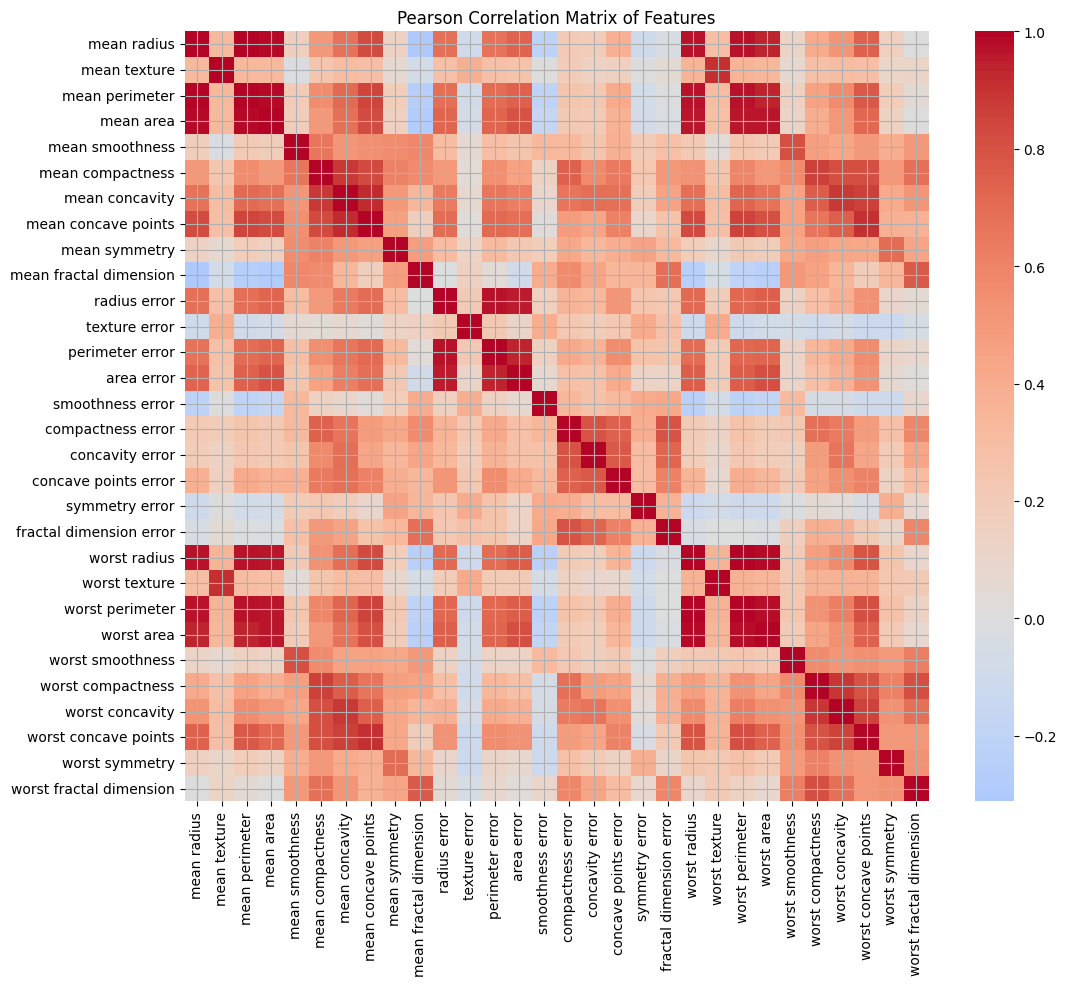

,,0
mean radius,mean perimeter,0.997855
worst perimeter,worst radius,0.993708
mean radius,mean area,0.987357


In [10]:
# Correlation Matrix

corr_matrix = df[numeric_cols].corr(method="pearson")

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Pearson Correlation Matrix of Features")
plt.show()

# Get top 3 most correlated feature pairs (absolute value, exclude self-correlation)
corr_unstacked = corr_matrix.abs().unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 1]  # remove self-correlations
top3_pairs = corr_unstacked.sort_values(ascending=False).drop_duplicates().head(3)
top3_pairs


**3.3Boxplot Analizi**

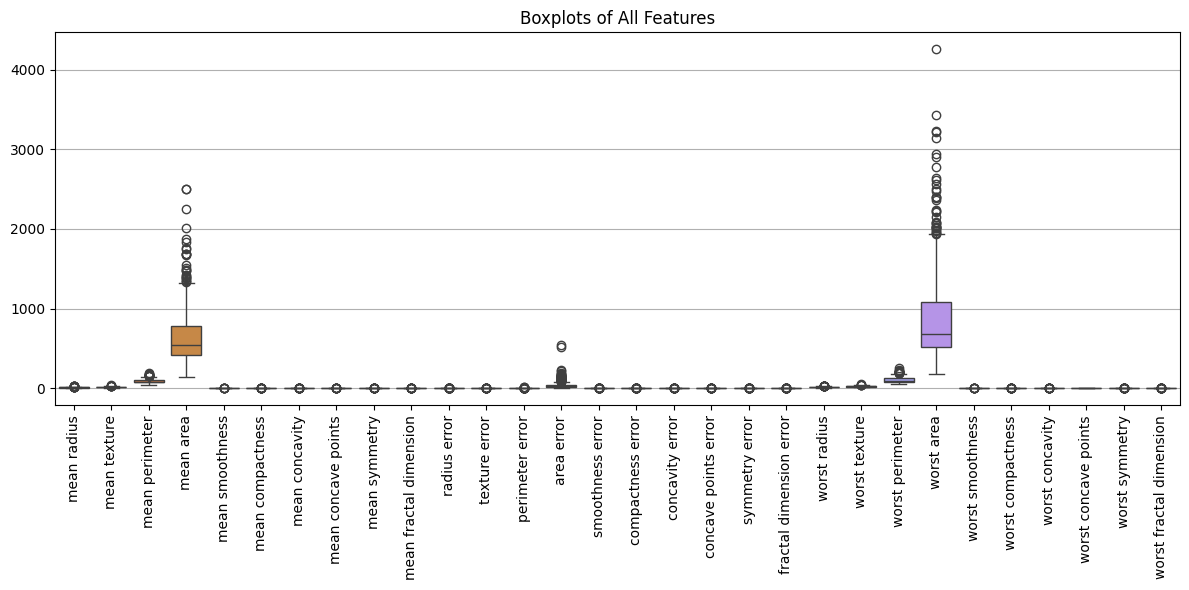

In [11]:
# Boxplots for all features (already plotted above, but we can focus by groups)

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=90)
plt.title("Boxplots of All Features")
plt.tight_layout()
plt.show()


**4. ve 5. Veri Setinin Bölünmesi ve Ölçeklendirme -Scaling**

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

X = df.drop("target", axis=1).values   # özellikler
y = df["target"].values                # hedef

# 60% train, 20% val, 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25,  # 0.25 * 0.8 = 0.2
    random_state=RANDOM_STATE, stratify=y_train_val
)

# !!! Sadece train'e göre scaler fit ediliyor
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

for name, y_split in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    unique, counts = np.unique(y_split, return_counts=True)
    print(f"{name} set class distribution:")
    for u, c in zip(unique, counts):
        print(f"  Class {u}: {c} samples ({c/len(y_split)*100:.1f}%)")


X_train shape: (341, 30)
y_train shape: (341,)
X_val shape: (114, 30)
y_val shape: (114,)
X_test shape: (114, 30)
y_test shape: (114,)
Train set class distribution:
  Class 0: 127 samples (37.2%)
  Class 1: 214 samples (62.8%)
Validation set class distribution:
  Class 0: 43 samples (37.7%)
  Class 1: 71 samples (62.3%)
Test set class distribution:
  Class 0: 42 samples (36.8%)
  Class 1: 72 samples (63.2%)


Veri sızıntısı düzeltmek için: Split → Sonra StandardScaler.fit sadece train’e, transform val/test’e.

**6.Farklı MLP Modellerinin Kurulması**

In [51]:

models = {}

# Model 1 – Simple
models["Model 1 - Simple"] = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation="relu",
    learning_rate_init=0.001,
    alpha=0.001,
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=20,
    validation_fraction=0.1,
    random_state=RANDOM_STATE
)

# Model 2 – Medium
models["Model 2 - Medium"] = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    learning_rate_init=0.003,
    alpha=0.001,
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=20,
    validation_fraction=0.1,
    random_state=RANDOM_STATE
)

# Model 3 – Wide
models["Model 3 - Wide"] = MLPClassifier(
    hidden_layer_sizes=(64, 64),
    activation="tanh",
    learning_rate_init=0.001,
    alpha=0.001,
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=20,
    validation_fraction=0.1,
    random_state=RANDOM_STATE
)

# Model 4 – Deep
models["Model 4 - Deep"] = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation="relu",
    learning_rate_init=0.0008,
    alpha=0.001,
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=20,
    validation_fraction=0.1,
    random_state=RANDOM_STATE
)

# Model 5 – Low Learning Rate
models["Model 5 - Low LR"] = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation="relu",
    learning_rate_init=0.0003,
    alpha=0.001,
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=20,
    validation_fraction=0.1,
    random_state=RANDOM_STATE
)



**7.Validation Performanslarının Ölçülmesi**

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

rows = []

for name, clf in models.items():
    clf.fit(X_train, y_train)
    print(f"{name} trained.")

    # validation
    y_val_pred = clf.predict(X_val)
    y_val_proba = clf.predict_proba(X_val)[:, 1]

    # test
    y_test_pred = clf.predict(X_test)
    y_test_proba = clf.predict_proba(X_test)[:, 1]

    rows.append({
        "Model": name,
        "Val_Accuracy":  accuracy_score(y_val, y_val_pred),
        "Test_Accuracy": accuracy_score(y_test, y_test_pred),
        "Test_Precision": precision_score(y_test, y_test_pred),
        "Test_Recall":    recall_score(y_test, y_test_pred),
        "Test_F1":        f1_score(y_test, y_test_pred),
        "Test_ROC_AUC":   roc_auc_score(y_test, y_test_proba)
    })

results = pd.DataFrame(rows)
print(results)

Model 1 - Simple trained.
Model 2 - Medium trained.
Model 3 - Wide trained.
Model 4 - Deep trained.
Model 5 - Low LR trained.
              Model  Val_Accuracy  Test_Accuracy  Test_Precision  Test_Recall  \
0  Model 1 - Simple      0.885965       0.894737        0.884615     0.958333   
1  Model 2 - Medium      0.938596       0.947368        0.971429     0.944444   
2    Model 3 - Wide      0.973684       0.956140        0.946667     0.986111   
3    Model 4 - Deep      0.964912       0.964912        0.972222     0.972222   
4  Model 5 - Low LR      0.868421       0.921053        0.898734     0.986111   

    Test_F1  Test_ROC_AUC  
0  0.920000      0.974206  
1  0.957746      0.993056  
2  0.965986      0.995370  
3  0.972222      0.996693  
4  0.940397      0.979167  


**8.En İyi Modelin Test Üzerinde Değerlendirilmesi**

In [53]:
# Selecting best model based on validation F1-score

best_model_name = val_results_df.iloc[0]["Model"]
best_model = models[best_model_name]
best_model_name


'Model 2 - Medium'

**8.1 Performans Metrikleri**

In [54]:
# Test Performance Metrics

test_acc, test_prec, test_rec, test_f1, test_roc_auc = evaluate_model(best_model, X_test, y_test)

print("Best Model:", best_model_name)
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall:    {test_rec:.4f}")
print(f"Test F1-score:  {test_f1:.4f}")
print(f"Test ROC-AUC:   {test_roc_auc:.4f}")


Best Model: Model 2 - Medium
Test Accuracy:  0.9474
Test Precision: 0.9714
Test Recall:    0.9444
Test F1-score:  0.9577
Test ROC-AUC:   0.9931


**8.2 Korelasyon Matrisi -Test Seti**

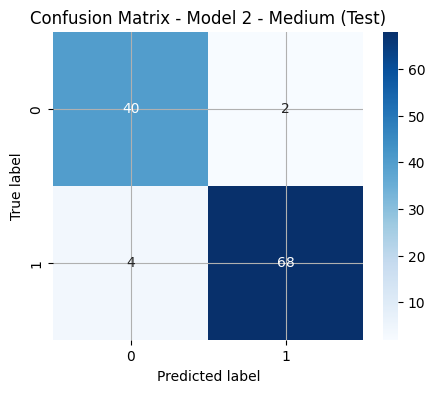

In [55]:
# Confusion Matrix (Test Set)

y_test_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion Matrix - {best_model_name} (Test)")
plt.show()


**8.3 ROC Eğrisi**

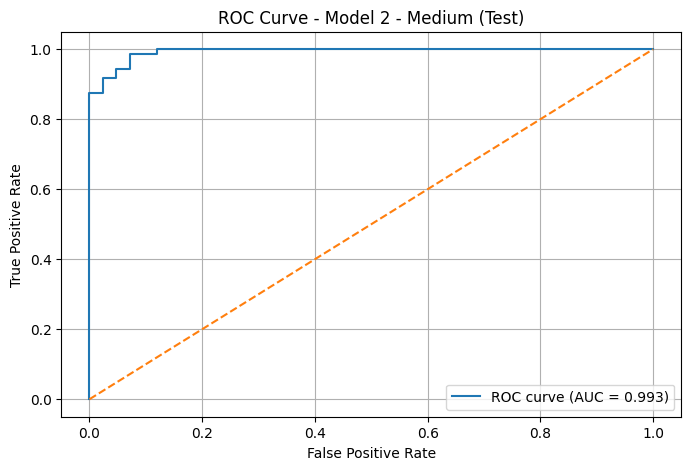

In [56]:
# ROC Curve

y_test_proba = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_model_name} (Test)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


**9.Optuna ile Hiperparametre Optimizasyonu -150 Deneme**

**9.1 Optuna Study Tanımı ve 9.2 Optuna Arama Aralıkları**

In [57]:
# Hyperparameter Optimization with Optuna (150 Trials)

def objective(trial):
    n_units1 = trial.suggest_int("n_units_l1", 16, 256)
    n_units2 = trial.suggest_int("n_units_l2", 8, 128)

    learning_rate_init = trial.suggest_loguniform("learning_rate_init", 1e-5, 1e-1)
    alpha = trial.suggest_loguniform("alpha", 1e-6, 1e-2)
    activation = trial.suggest_categorical("activation", ["relu", "tanh"])
    solver = trial.suggest_categorical("solver", ["adam", "sgd"])
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])

    clf = MLPClassifier(
        hidden_layer_sizes=(n_units1, n_units2),
        learning_rate_init=learning_rate_init,
        alpha=alpha,
        activation=activation,
        solver=solver,
        batch_size=batch_size,
        max_iter=500,
        random_state=RANDOM_STATE
    )

    clf.fit(X_train, y_train)

    _, _, _, f1, _ = evaluate_model(clf, X_val, y_val)
    return f1

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=150)

print("Number of finished trials:", len(study.trials))
print("Best trial F1-score:", study.best_value)
print("Best params:", study.best_trial.params)


[I 2025-11-27 08:31:09,397] A new study created in memory with name: no-name-d0f980d1-2d10-4db6-92b1-93825fbbfbe7
[I 2025-11-27 08:31:22,927] Trial 0 finished with value: 0.9859154929577465 and parameters: {'n_units_l1': 232, 'n_units_l2': 107, 'learning_rate_init': 1.3943694368358075e-05, 'alpha': 0.00034706224856212854, 'activation': 'tanh', 'solver': 'adam', 'batch_size': 16}. Best is trial 0 with value: 0.9859154929577465.
[I 2025-11-27 08:31:23,373] Trial 1 finished with value: 0.9859154929577465 and parameters: {'n_units_l1': 213, 'n_units_l2': 56, 'learning_rate_init': 0.04123228239790332, 'alpha': 0.0004253311541622285, 'activation': 'relu', 'solver': 'sgd', 'batch_size': 32}. Best is trial 0 with value: 0.9859154929577465.
[I 2025-11-27 08:31:23,834] Trial 2 finished with value: 0.9787234042553191 and parameters: {'n_units_l1': 249, 'n_units_l2': 19, 'learning_rate_init': 0.04522571366499944, 'alpha': 2.2191000643826927e-06, 'activation': 'tanh', 'solver': 'adam', 'batch_size'

Number of finished trials: 150
Best trial F1-score: 0.993006993006993
Best params: {'n_units_l1': 142, 'n_units_l2': 29, 'learning_rate_init': 0.016852988187972397, 'alpha': 0.00012250016245703754, 'activation': 'relu', 'solver': 'adam', 'batch_size': 16}


**9.3 Eğitim Döngüsü ve 9.4 En İyi Trial’ın Raporlanması**

In [58]:
best_trial = study.best_trial
best_params = best_trial.params

print("Best Trial Number:", best_trial.number)
print("Best Validation F1-score:", best_trial.value)
print("Best Parameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")


Best Trial Number: 6
Best Validation F1-score: 0.993006993006993
Best Parameters:
  n_units_l1: 142
  n_units_l2: 29
  learning_rate_init: 0.016852988187972397
  alpha: 0.00012250016245703754
  activation: relu
  solver: adam
  batch_size: 16


In [60]:
# Re-train best Optuna model on train+val for later SHAP analysis

X_train_val = np.vstack([X_train, X_val])
y_train_val = np.concatenate([y_train, y_val])

optuna_best_clf = MLPClassifier(
    hidden_layer_sizes=(best_params["n_units_l1"], best_params["n_units_l2"]),
    learning_rate_init=best_params["learning_rate_init"],
    alpha=best_params["alpha"],
    activation=best_params["activation"],
    solver=best_params["solver"],
    batch_size=best_params["batch_size"],
    max_iter=500,
    random_state=RANDOM_STATE
)

optuna_best_clf.fit(X_train_val, y_train_val)

# Evaluate on test set
opt_test_acc, opt_test_prec, opt_test_rec, opt_test_f1, opt_test_roc_auc = evaluate_model(optuna_best_clf, X_test, y_test)
print("\nOptuna Best Model Test Performance:")
print(f"Accuracy:  {opt_test_acc:.4f}")
print(f"Precision: {opt_test_prec:.4f}")
print(f"Recall:    {opt_test_rec:.4f}")
print(f"F1-score:  {opt_test_f1:.4f}")
print(f"ROC-AUC:   {opt_test_roc_auc:.4f}")



Optuna Best Model Test Performance:
Accuracy:  0.9561
Precision: 0.9855
Recall:    0.9444
F1-score:  0.9645
ROC-AUC:   0.9937


**10.XAI - SHAP Açıklanabilirlik Analizi**

**10.1 Beş MLP Modelinden validasyon başarısına göre seçilen model için SHAP Analizi**

In [61]:
# SHAP for Best of the Five MLP Models

# Choose a small background set
background_size = 50
test_sample_size = 100

background_idx = np.random.choice(X_train.shape[0], size=background_size, replace=False)
X_background = X_train[background_idx]

explainer_best = shap.KernelExplainer(best_model.predict_proba, X_background)

# Use subset of test data for SHAP computation
test_idx = np.random.choice(X_test.shape[0], size=min(test_sample_size, X_test.shape[0]), replace=False)
X_test_subset = X_test[test_idx]

shap_values_best = explainer_best.shap_values(X_test_subset)


  0%|          | 0/100 [00:00<?, ?it/s]

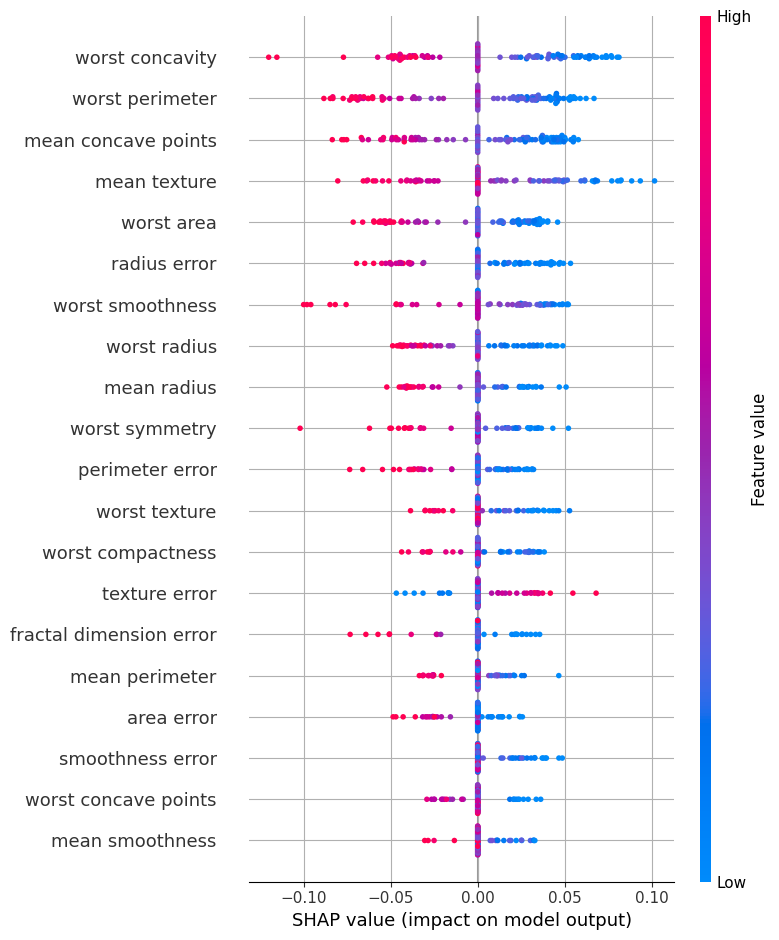

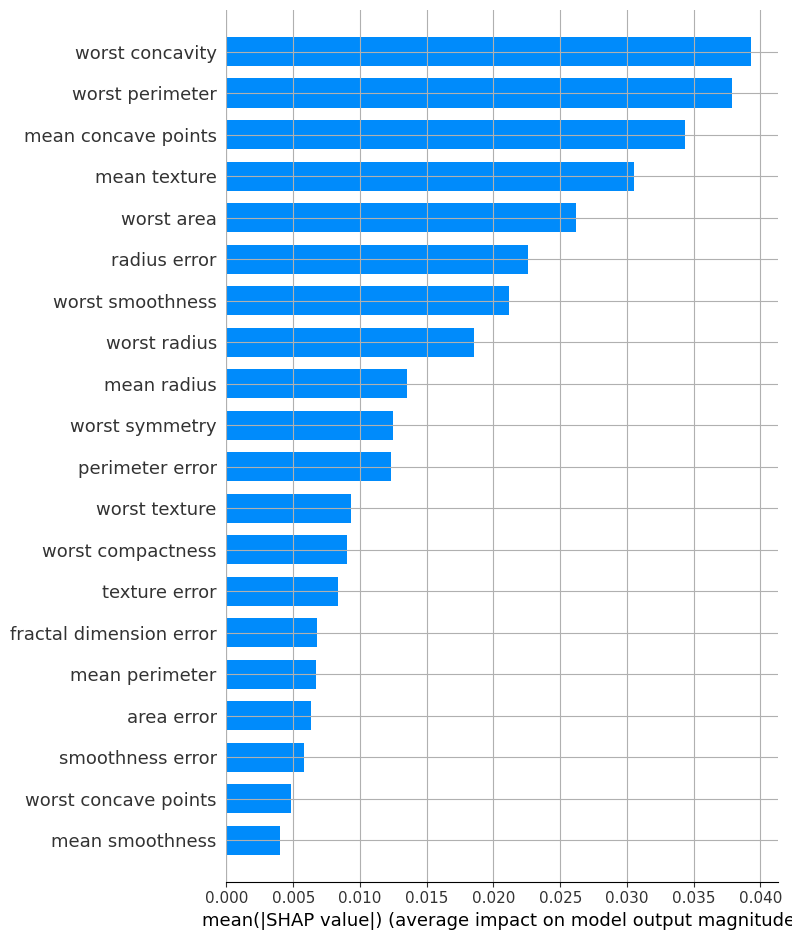

In [62]:
# For binary classification, shap_values_best can sometimes be a list of length 2
# (class 0 and class 1), where each element is (n_samples, n_features).
# However, the current output of KernelExplainer.shap_values is a 3D array
# of shape (n_samples, n_features, n_classes).
# To get SHAP values for class 1 for all samples, we need to slice it correctly.
shap_values_class1 = shap_values_best[:, :, 1]

shap.initjs()

# Summary plot (dot)
shap.summary_plot(shap_values_class1, X_test_subset, feature_names=numeric_cols)

# Bar plot (global feature importance)
shap.summary_plot(shap_values_class1, X_test_subset, feature_names=numeric_cols, plot_type="bar")

**10.2 Optuna En İyi Model için SHAP Analizi**

In [64]:
# SHAP for Optuna Best Model

background_idx_opt = np.random.choice(X_train_val.shape[0], size=background_size, replace=False)
X_background_opt = X_train_val[background_idx_opt]

explainer_optuna = shap.KernelExplainer(optuna_best_clf.predict_proba, X_background_opt)

test_idx_opt = np.random.choice(X_test.shape[0], size=min(test_sample_size, X_test.shape[0]), replace=False)
X_test_subset_opt = X_test[test_idx_opt]

shap_values_optuna = explainer_optuna.shap_values(X_test_subset_opt)


  0%|          | 0/100 [00:00<?, ?it/s]

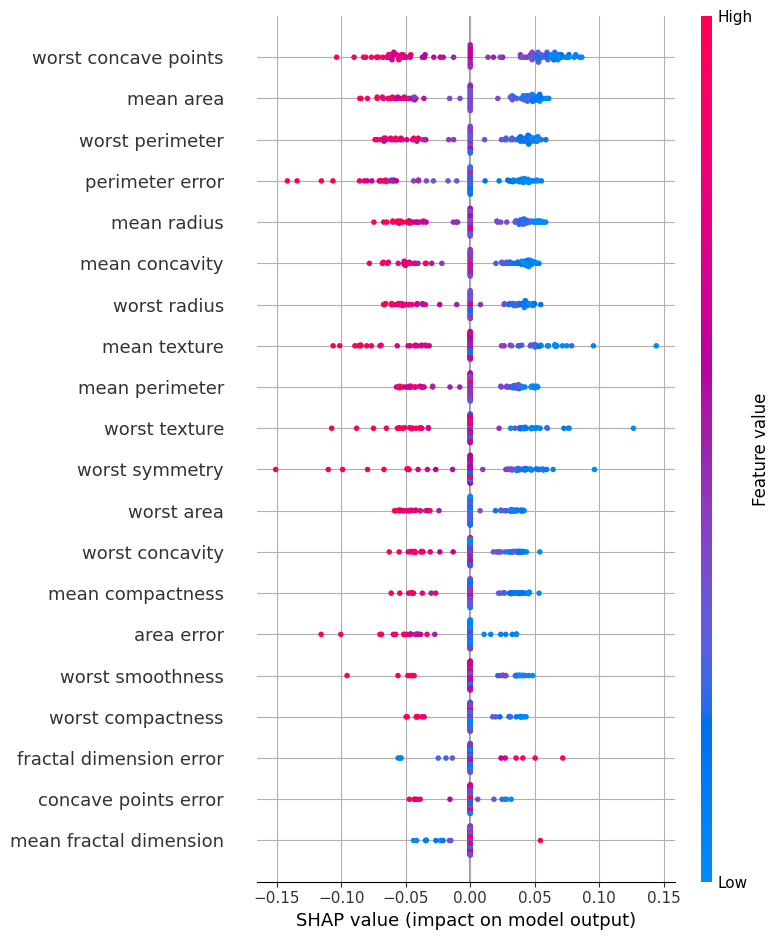

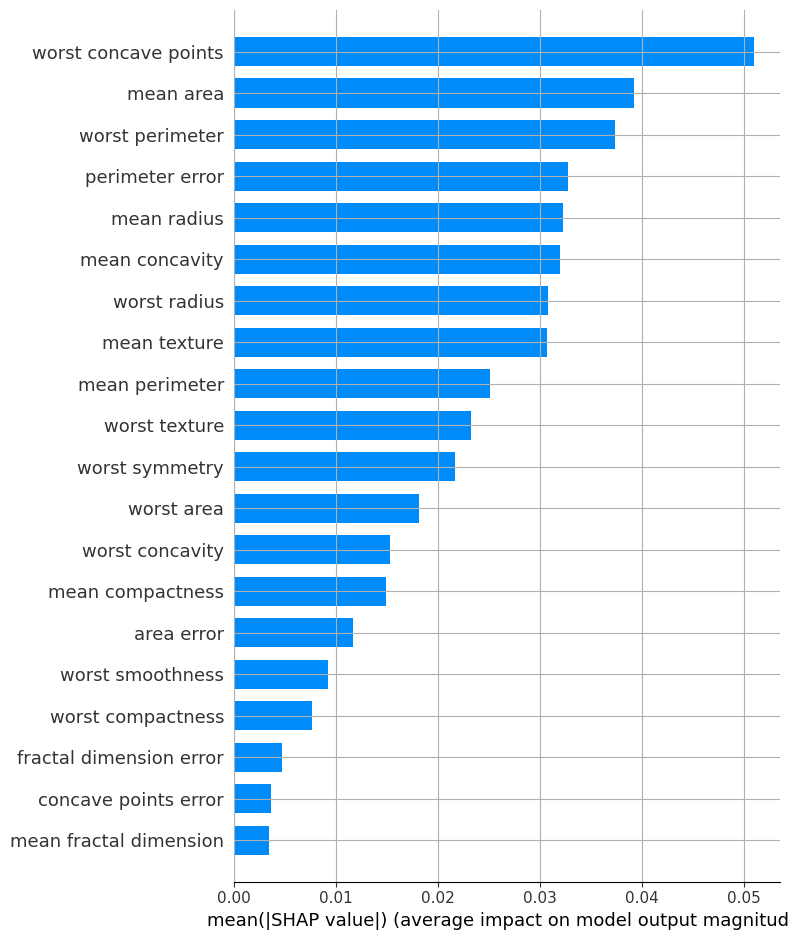

In [ ]:
# Summary plot for Optuna model (positive class)
shap.summary_plot(shap_values_optuna[:, :, 1], X_test_subset_opt, feature_names=numeric_cols)

# Bar plot for Optuna model
shap.summary_plot(shap_values_optuna[:, :, 1], X_test_subset_opt, feature_names=numeric_cols, plot_type="bar")

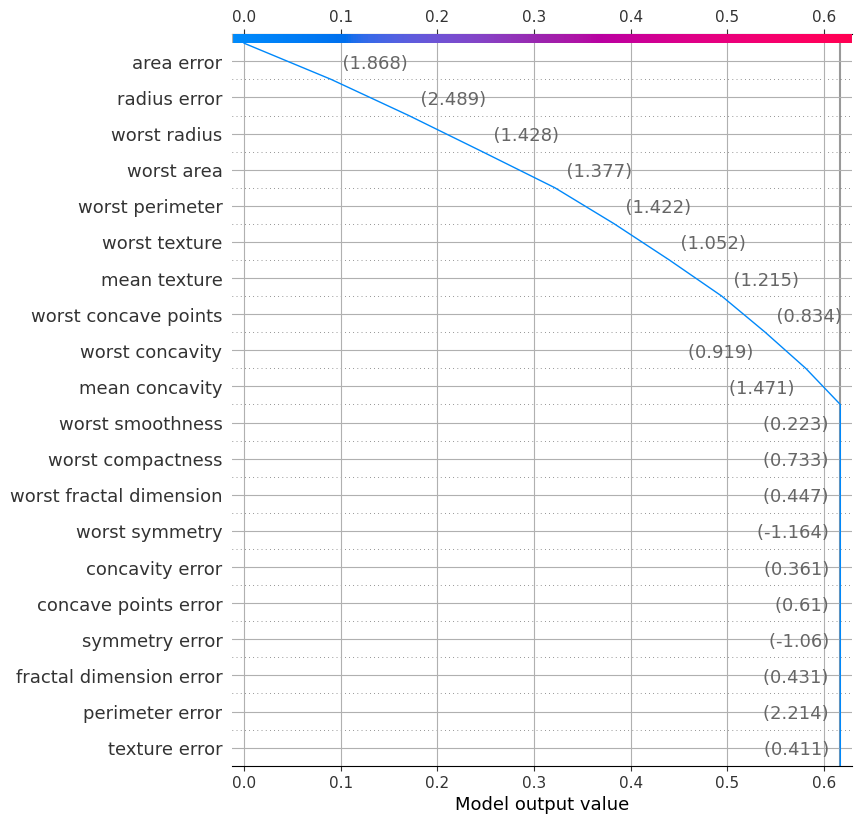

In [66]:
# Choose a single instance
i = 0  # index in X_test_subset_opt
instance = X_test_subset_opt[i:i+1]

# Force plot
shap.initjs()
shap.force_plot(
    explainer_optuna.expected_value[1],
    shap_values_optuna[i, :, 1], # Corrected slicing for SHAP values
    instance[0], # Pass 1D array of feature values
    feature_names=numeric_cols
)

# Decision plot
shap.decision_plot(
    explainer_optuna.expected_value[1],
    shap_values_optuna[i, :, 1], # Corrected slicing for SHAP values
    feature_names=numeric_cols,
    features=instance[0] # Pass 1D array of feature values
)